In [1]:
abstract type Element end

struct Resistor <: Element
    n1::Int
    n2::Int
    R::Float64
end

struct Capacitor <: Element
    n1::Int
    n2::Int
    C::Float64
end

struct Inductor <: Element
    n1::Int
    n2::Int
    L::Float64
end

struct VoltageSource
    n1::Int
    n2::Int
    value::Float64  # For time: can be a function
end

In [2]:
function stamp!(G, b, n1, n2, value)
    if n1 != 0
        G[n1, n1] += value
        if n2 != 0
            G[n1, n2] -= value
            G[n2, n1] -= value
            G[n2, n2] += value
        end
    elseif n2 != 0
        G[n2, n2] += value
    end
end

stamp! (generic function with 1 method)

In [9]:
function simulate_ac_mna(elements, vsrcs, freqs, n_nodes)
    n_vsources = length(vsrcs)
    N = n_nodes + n_vsources
    V = zeros(ComplexF64, length(freqs), n_nodes)

    for (i, f) in enumerate(freqs)
        ω = 2π * f
        G = zeros(ComplexF64, N, N)
        b = zeros(ComplexF64, N)

        # Stamp passive elements
        for el in elements
            if el isa Resistor
                stamp!(G, b, el.n1, el.n2, 1 / el.R)
            elseif el isa Capacitor
                stamp!(G, b, el.n1, el.n2, im * ω * el.C)
            elseif el isa Inductor
                stamp!(G, b, el.n1, el.n2, 1 / (im * ω * el.L))
            end
        end

        # Stamp voltage sources
        for (k, src) in enumerate(vsrcs)
            row = n_nodes + k
            if src.n1 != 0
                G[row, src.n1] = 1
                G[src.n1, row] = 1
            end
            if src.n2 != 0
                G[row, src.n2] = -1
                G[src.n2, row] = -1
            end
            b[row] = src.value
        end

        x = G \ b
        V[i, :] = x[1:n_nodes]
    end

    return V
end

simulate_ac_mna (generic function with 1 method)

In [ ]:
function ground_truth_rlc(freqs, R, L, C)
    ω = 2π .* freqs
    Z_R = R
    Z_L = im .* ω .* L
    Z_C = 1 ./ (im .* ω .* C)
    H = Z_C ./ (Z_R .+ Z_L .+ Z_C)
    return H
end

ground_truth_rlc (generic function with 1 method)

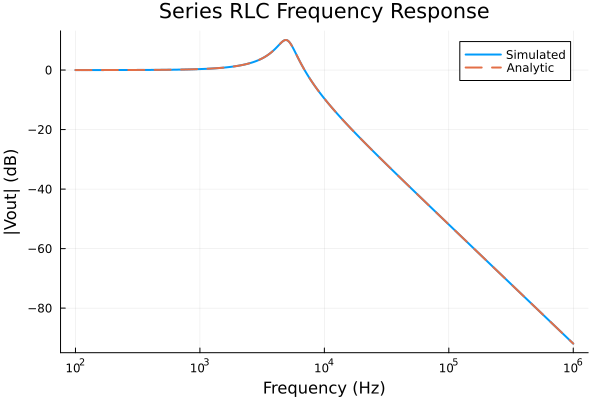

In [10]:
elements = [
    Resistor(1, 2, 10.0),
    Inductor(2, 3, 1e-3),
    Capacitor(3, 0, 1e-6)
]
sources = [VoltageSource(1, 0, 1.0)]
freqs = 10 .^ range(2, stop=6, length=500)

V_sim = simulate_ac_mna(elements, sources, freqs, 3)
Vout = V_sim[:, 3]

H = ground_truth_rlc(freqs, 10.0, 1e-3, 1e-6)

plot(freqs, 20 .* log10.(abs.(Vout)), xscale=:log10,
     xlabel="Frequency (Hz)", ylabel="|Vout| (dB)", label="Simulated", lw=2)
plot!(freqs, 20 .* log10.(abs.(H)), label="Analytic", lw=2, ls=:dash,
      title="Series RLC Frequency Response")

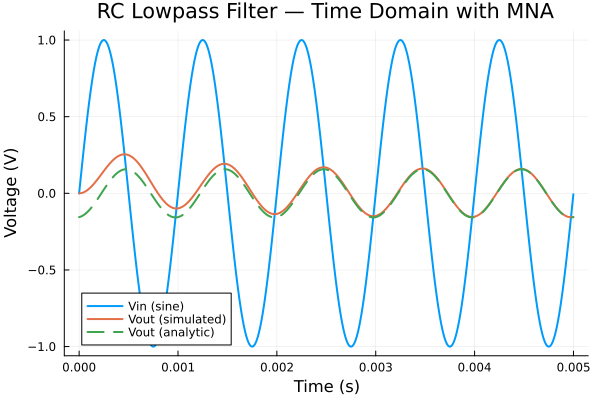

In [ ]:
# rc_mna_time_domain.jl

using LinearAlgebra
using Plots

###############################
# ELEMENT DEFINITIONS
###############################
abstract type Element end

struct Resistor <: Element
    n1::Int
    n2::Int
    R::Float64
end

struct Capacitor <: Element
    n1::Int
    n2::Int
    C::Float64
    id::Int  # for internal tracking
end

struct VoltageSource
    n1::Int
    n2::Int
    value::Function  # value(t)
end

###############################
# STAMP HELPERS
###############################
function stamp_G!(G, n1, n2, value)
    if n1 != 0
        G[n1, n1] += value
        if n2 != 0
            G[n1, n2] -= value
            G[n2, n1] -= value
            G[n2, n2] += value
        end
    elseif n2 != 0
        G[n2, n2] += value
    end
end

###############################
# TIME DOMAIN MNA SIMULATION
###############################
function simulate_time_mna(elements, vsources, dt, tmax, n_nodes)
    N = Int(round(tmax / dt))
    t = range(0, step=dt, length=N)

    n_vs = length(vsources)
    n_cap = count(el -> el isa Capacitor, elements)

    total_vars = n_nodes + n_vs
    V = zeros(N, n_nodes)

    G = zeros(Float64, total_vars, total_vars)
    Cmat = zeros(Float64, total_vars, total_vars)
    b_static = zeros(Float64, total_vars)

    # Track capacitor voltage for backward Euler
    cap_ids = Dict{Int, Tuple{Int, Int, Float64}}()  # id => (n1, n2, C)
    cid = 1
    for el in elements
        if el isa Capacitor
            cap_ids[cid] = (el.n1, el.n2, el.C)
            cid += 1
        elseif el isa Resistor
            stamp_G!(G, el.n1, el.n2, 1 / el.R)
        end
    end

    # Voltage source stamping (MNA rows)
    for (k, src) in enumerate(vsources)
        row = n_nodes + k
        if src.n1 != 0
            G[row, src.n1] = 1
            G[src.n1, row] = 1
        end
        if src.n2 != 0
            G[row, src.n2] = -1
            G[src.n2, row] = -1
        end
    end

    # Capacitor C matrix stamping
    for (cid, (n1, n2, Cval)) in cap_ids
        g = Cval / dt
        stamp_G!(Cmat, n1, n2, g)
    end

    x_prev = zeros(Float64, total_vars)

    for (k, tk) in enumerate(t)
        b = copy(b_static)

        # Capacitor source vector: i = C * (v_now - v_prev) / dt => i_prev = C * v_prev / dt
        i_prev = Cmat * x_prev
        b += i_prev

        # Voltage sources
        for (idx, src) in enumerate(vsources)
            row = n_nodes + idx
            b[row] = src.value(tk)
        end

        x = (G + Cmat) \ b
        V[k, :] .= x[1:n_nodes]
        x_prev .= x
    end

    return t, V
end

###############################
# TEST BENCH: RC LOWPASS
###############################
# Define parameters
f = 1e3
ω = 2π * f
R = 1e3
C = 1e-6
dt = 1e-6
tmax = 5e-3

# Circuit: 1 --- R --- 2 --- C --- 0
# Vin applied at node 1
n_nodes = 2

elements = [
    Resistor(1, 2, R),
    Capacitor(2, 0, C, 1)
]

vsources = [VoltageSource(1, 0, t -> sin(ω * t))]

t, V = simulate_time_mna(elements, vsources, dt, tmax, n_nodes)
vout_sim = V[:, 2]

# Ground truth
H = 1 / (1 + im * ω * R * C)
mag = abs(H)
phase = angle(H)
vout_analytic = mag .* sin.(ω .* t .+ phase)

# Plot
plot(t, sin.(ω .* t), label="Vin (sine)", lw=2)
plot!(t, vout_sim, label="Vout (simulated)", lw=2)
plot!(t, vout_analytic, label="Vout (analytic)", lw=2, ls=:dash,
      title="RC Lowpass Filter — Time Domain with MNA",
      xlabel="Time (s)", ylabel="Voltage (V)")

In [12]:
# mna_trapezoidal_sim.jl — Stable MNA Time-Domain Simulator with Trapezoidal or Gear2 Time Integration (Fixed Gear2 Bootstrapping)

using LinearAlgebra
using Plots
using CSV
using DataFrames

########################################
# ELEMENT DEFINITIONS
########################################
abstract type Element end

struct Resistor <: Element
    n1::Int
    n2::Int
    R::Float64
end

struct Capacitor <: Element
    n1::Int
    n2::Int
    C::Float64
    id::Int
end

struct Inductor <: Element
    n1::Int
    n2::Int
    L::Float64
    id::Int
end

struct VoltageSource
    n1::Int
    n2::Int
    value::Function
end

########################################
# STAMPING UTILITIES
########################################
function stamp_G!(G, n1, n2, value)
    if n1 != 0
        G[n1, n1] += value
        if n2 != 0
            G[n1, n2] -= value
            G[n2, n1] -= value
            G[n2, n2] += value
        end
    elseif n2 != 0
        G[n2, n2] += value
    end
end

function ensure_grounded!(elements::Vector{Element}, n_nodes::Int; R_shunt=1e12)
    connected = falses(n_nodes)
    for el in elements
        if el isa Resistor || el isa Capacitor || el isa Inductor
            for n in (el.n1, el.n2)
                if n != 0
                    connected[n] = true
                end
            end
        end
    end
    for n in 1:n_nodes
        if connected[n] && !(any(e -> e isa Resistor && ((e.n1 == n && e.n2 == 0) || (e.n2 == n && e.n1 == 0)), elements))
            push!(elements, Resistor(n, 0, R_shunt))
        end
    end
end

########################################
# TIME-DOMAIN MNA SOLVER WITH INTEGRATION METHOD FLAG
########################################
function simulate_time_mna(elements, vsources, dt, tmax, n_nodes; method=:trap, debug=false)
    ensure_grounded!(elements, n_nodes)
    N = Int(round(tmax / dt))
    t = range(0, step=dt, length=N)

    n_vs = length(vsources)
    inductors = filter(e -> e isa Inductor, elements)
    capacitors = filter(e -> e isa Capacitor, elements)
    n_L = length(inductors)

    total_vars = n_nodes + n_vs + n_L
    V = zeros(N, n_nodes)
    Vin = zeros(N)

    G = zeros(Float64, total_vars, total_vars)
    Cmat = zeros(Float64, total_vars, total_vars)
    b_static = zeros(Float64, total_vars)

    L_map = Dict{Int, Tuple{Int, Int, Float64, Int}}()
    C_map = Dict{Int, Tuple{Int, Int, Float64}}()
    iL_offset = n_nodes + n_vs
    row_L = 1

    for el in elements
        if el isa Resistor
            stamp_G!(G, el.n1, el.n2, 1 / el.R)
        elseif el isa Capacitor
            C_map[el.id] = (el.n1, el.n2, el.C)
        elseif el isa Inductor
            n1, n2, L, id = el.n1, el.n2, el.L, el.id
            row = iL_offset + row_L
            L_map[id] = (n1, n2, L, row)
            if n1 != 0
                G[row, n1] = 1; G[n1, row] = 1
            end
            if n2 != 0
                G[row, n2] = -1; G[n2, row] = -1
            end
            Cmat[row, row] = -L
            row_L += 1
        end
    end

    for (k, src) in enumerate(vsources)
        row = n_nodes + k
        if src.n1 != 0
            G[row, src.n1] = 1; G[src.n1, row] = 1
        end
        if src.n2 != 0
            G[row, src.n2] = -1; G[src.n2, row] = -1
        end
    end

    for (_, (n1, n2, Cval)) in C_map
        stamp_G!(Cmat, n1, n2, Cval)
    end

    A = G + (2 / dt) * Cmat
    F = lu(A)

    x_prev = zeros(Float64, total_vars)
    x_prev2 = zeros(Float64, total_vars)

    for (k, tk) in enumerate(t)
        b = copy(b_static)

        if method == :trap || (method == :gear && k <= 2)
            b += Cmat * ((2 / dt) * x_prev)
        elseif method == :gear
            b += Cmat * ((1.5 / dt) * x_prev - (0.5 / dt) * x_prev2)
        end

        for (i, src) in enumerate(vsources)
            row = n_nodes + i
            val = src.value(tk)
            b[row] = val
            Vin[k] = val
        end

        x = F \ b

        if any(isnan.(x)) || any(isinf.(x))
            @warn "Invalid x at step $k (t=$(tk)):" cond_A = cond(A); @show cond_A; display(x)
            error("Aborting: x contains NaN or Inf")
        end

        if debug && (k % 100 == 0)
            println("Step $k t=$(tk*1e9) ns | max|x| = $(maximum(abs.(x))) | cond(A) = $(log10(cond(A)))")
        end

        V[k, 1:n_nodes] .= x[1:n_nodes]
        x_prev2 .= x_prev
        x_prev .= x
    end

    return t, V, Vin
end

########################################
# TESTBENCH — BANDPASS WITH INTEGRATION COMPARISON
########################################
f0 = 1e9
Q = 10.0
R = 50.0
L = Q * R / (2π * f0)
C = 1 / ((2π * f0)^2 * L)

frequencies = [f0]
labels = ["f0 = 1GHz"]
dt = 1e-14
Tmax = 3e-8
n_nodes = 3

methods = [:trap, :gear]

for method in methods
    for (i, f) in enumerate(frequencies)
        elements = [
            Resistor(1, 2, R),
            Inductor(2, 3, L, 1),
            Capacitor(3, 0, C, 1)
        ]

        vsources = [VoltageSource(1, 0, t -> sin(2π * f * t))]
        t, V, Vin = simulate_time_mna(elements, vsources, dt, Tmax, n_nodes; method=method)
        vout = V[:, 3]

        df = DataFrame(Time = t, Vin = Vin, Vout = vout)
        fname = "bandpass_$(method)_$(labels[i]).csv"
        CSV.write(fname, df)
        println("Saved simulation results for $(labels[i]) using $(method) to $(fname)")
    end
end

Saved simulation results for f0 = 1GHz using trap to bandpass_trap_f0 = 1GHz.csv
Saved simulation results for f0 = 1GHz using gear to bandpass_gear_f0 = 1GHz.csv


## Switched cap analysis

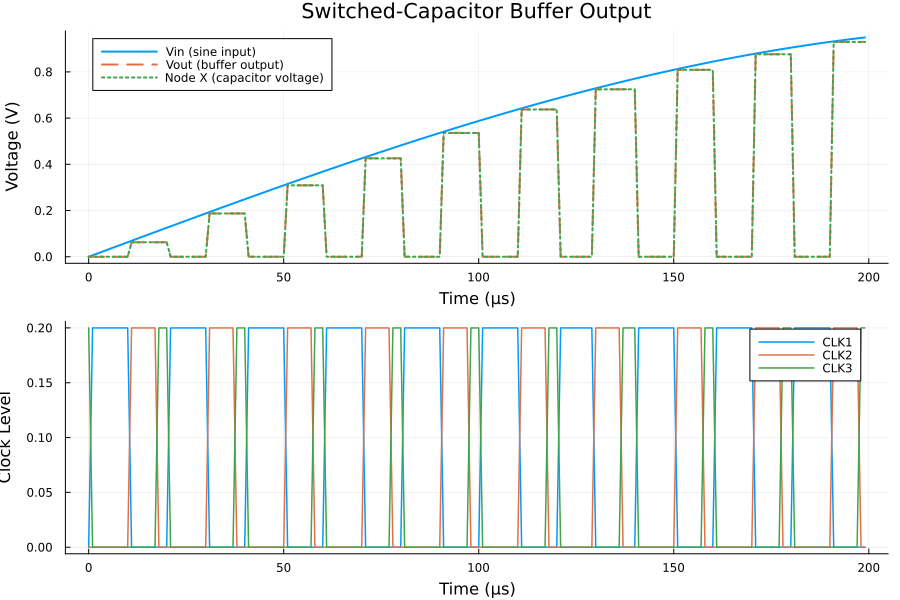

In [4]:
using Plots

# Simulation parameters
fs = 1e6             # sampling frequency
T = 1 / fs           # time step
t_end = 200e-6       # total simulation time
t = 0:T:(t_end - T)

# Input sine wave
f_in = 1e3
vin = sin.(2π * f_in .* t)

# Clock signals (non-overlapping 3-phase)
f_clk = 50e3
clk1 = (sin.(2π * f_clk .* t) .> 0)
clk2 = circshift(clk1, round(Int, 0.33 * fs / f_clk)) .& .!clk1
clk3 = circshift(clk1, round(Int, 0.66 * fs / f_clk)) .& .!clk1 .& .!clk2

# Initialize states
ch = 0.0
vx = zeros(length(t))
vout = zeros(length(t))

# Simulation loop
for i in 2:length(t)
    if clk1[i]
        ch = vin[i]
    elseif clk2[i]
        vx[i] = ch
        vout[i] = ch
    elseif clk3[i]
        vx[i] = ch
        vout[i] = ch
    else
        vx[i] = vx[i-1]
        vout[i] = vout[i-1]
    end
end

# Plot waveforms
p1 = plot(t .* 1e6, vin, label="Vin (sine input)", xlabel="Time (µs)", ylabel="Voltage (V)", title="Switched-Capacitor Buffer Output", linewidth=2)
plot!(p1, t .* 1e6, vout, label="Vout (buffer output)", linewidth=2, linestyle=:dash)
plot!(p1, t .* 1e6, vx, label="Node X (capacitor voltage)", linewidth=2, linestyle=:dot)

# Plot clocks in a separate subplot
p2 = plot(t .* 1e6, clk1 .* 0.2, label="CLK1", xlabel="Time (µs)", ylabel="Clock Level", lw=1.5)
plot!(p2, t .* 1e6, clk2 .* 0.2, label="CLK2", lw=1.5)
plot!(p2, t .* 1e6, clk3 .* 0.2, label="CLK3", lw=1.5)

# Combine plots
plot(p1, p2, layout = @layout([a; b]), size=(900, 600))

## Non inverting accumulator
$V_{\text{out}} = \left(1 + \frac{C_1}{C_2}\right) V_{\text{in}}$
i.e. 

$V_{\text{out}}[n+1] = V_{\text{out}}[n] + \frac{C_1}{C_2} V_{\text{in}}[n]$

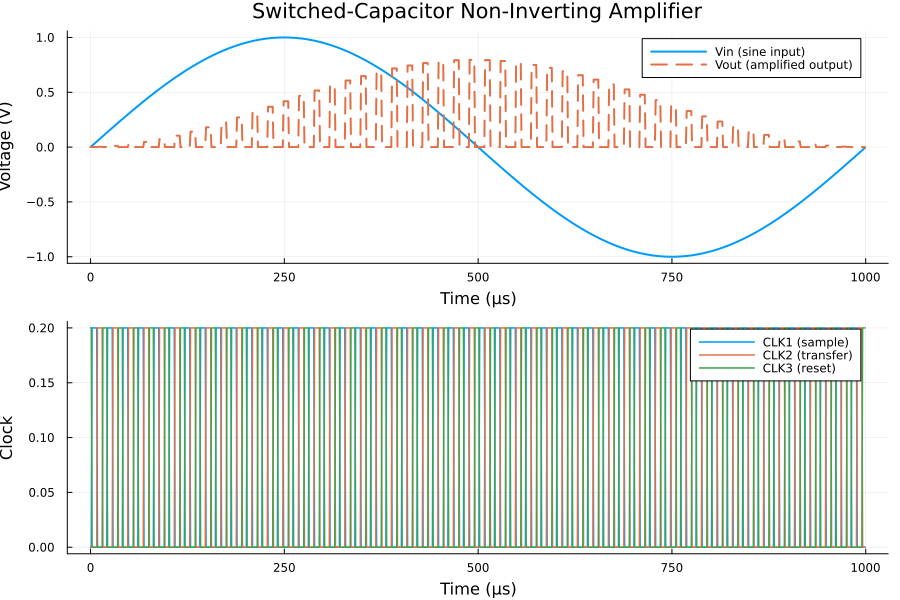

In [12]:

using Plots

# Simulation parameters
fs = 1e6
T = 1 / fs
t_end = 1000e-6
t = 0:T:(t_end - T)

# Input signal
f_in = 1e3
vin = sin.(2π * f_in .* t)

# Clock signals (three non-overlapping phases)
f_clk = 50e3
clk_raw = sin.(2π * f_clk .* t)
clk1 = clk_raw .> 0.5
clk2 = circshift(clk1, round(Int, 0.33 * fs / f_clk)) .& .!clk1
clk3 = circshift(clk1, round(Int, 0.66 * fs / f_clk)) .& .!clk1 .& .!clk2

# Capacitance values
C1 = 1.0
C2 = 20.0

# Initialize
vout = zeros(length(t))
vout_prev = 0.0
q1 = 0.0  # charge on C1

# Simulation loop
for i in 2:length(t)
    if clk3[i]  # Reset phase (S3)
        q1 = 0.0
    elseif clk1[i]  # Sample phase (S1)
        q1 = C1 * vin[i]
    elseif clk2[i]  # Transfer phase (S2)
        delta_q = q1
        delta_vout = delta_q / C2
        vout[i] = vout_prev + delta_vout
        vout_prev = vout[i]
        q1 = 0.0  # prevent re-transfer in future cycles
    else
        vout[i] = vout[i-1]
    end
end

# Plot signal and clocks
p1 = plot(t .* 1e6, vin, label="Vin (sine input)", xlabel="Time (µs)", ylabel="Voltage (V)", title="Switched-Capacitor Non-Inverting Amplifier", linewidth=2)
plot!(p1, t .* 1e6, vout, label="Vout (amplified output)", linewidth=2, linestyle=:dash)

p2 = plot(t .* 1e6, clk1 .* 0.2, label="CLK1 (sample)", xlabel="Time (µs)", ylabel="Clock", lw=1.5)
plot!(p2, t .* 1e6, clk2 .* 0.2, label="CLK2 (transfer)", lw=1.5)
plot!(p2, t .* 1e6, clk3 .* 0.2, label="CLK3 (reset)", lw=1.5)

plot(p1, p2, layout = @layout([a; b]), size=(900, 600))


# non-inverting amplifier
Transfer vout then immediately reset it

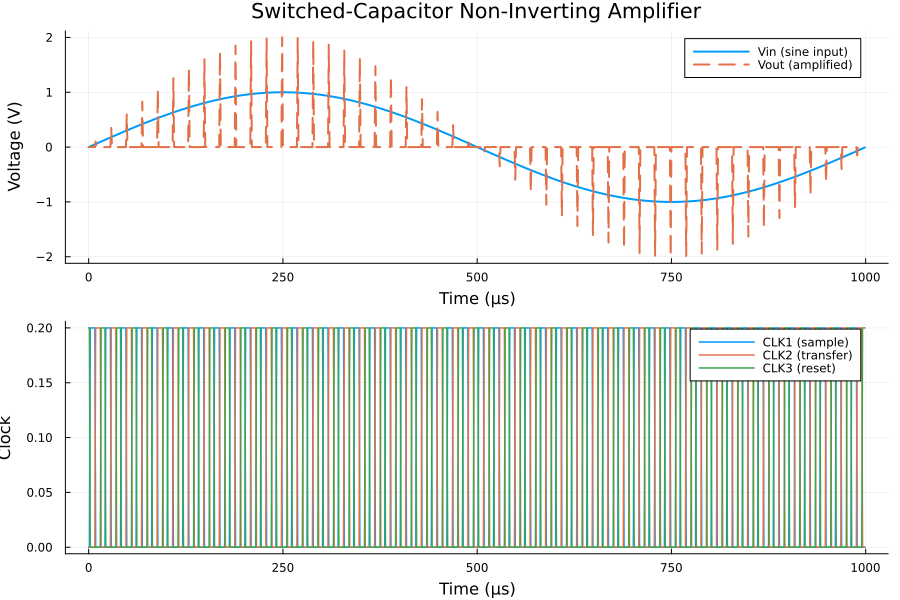

In [15]:
using Plots

# Simulation parameters
fs = 1e6
T = 1 / fs
t_end = 1000e-6
t = 0:T:(t_end - T)

# Input signal
f_in = 1e3
vin = sin.(2π * f_in .* t)

# Clock signals (three-phase non-overlapping)
f_clk = 50e3
clk_raw = sin.(2π * f_clk .* t)
clk1 = clk_raw .> 0.5                             # Sample
clk2 = circshift(clk1, round(Int, 0.33 * fs / f_clk)) .& .!clk1  # Transfer
clk3 = circshift(clk1, round(Int, 0.66 * fs / f_clk)) .& .!clk1 .& .!clk2  # Reset

# Capacitances
C1 = 4.0
C2 = 2.0

# State variables
vout = zeros(length(t))
q1 = 0.0

# Simulation loop
for i in 2:length(t)
    if clk3[i]       # Reset C1
        q1 = 0.0
        vout[i] = 0.0
    elseif clk1[i]   # Sample Vin
        q1 = C1 * vin[i]
    elseif clk2[i]   # Transfer to C2, no accumulation
        delta_vout = q1 / C2
        vout[i] = delta_vout
        q1 = 0.0
    else             # Hold
        vout[i] = vout[i-1]
    end
end

# Plot waveforms
p1 = plot(t .* 1e6, vin, label="Vin (sine input)", xlabel="Time (µs)", ylabel="Voltage (V)",
          title="Switched-Capacitor Non-Inverting Amplifier", linewidth=2)
plot!(p1, t .* 1e6, vout, label="Vout (amplified)", linewidth=2, linestyle=:dash)

p2 = plot(t .* 1e6, clk1 .* 0.2, label="CLK1 (sample)", xlabel="Time (µs)", ylabel="Clock", lw=1.5)
plot!(p2, t .* 1e6, clk2 .* 0.2, label="CLK2 (transfer)", lw=1.5)
plot!(p2, t .* 1e6, clk3 .* 0.2, label="CLK3 (reset)", lw=1.5)

plot(p1, p2, layout = @layout([a; b]), size=(900, 600))

# Analog VCO Modelling

In [1]:
using CSV, DataFrames, Plots


In [2]:
module VCRO
using Random 
export VCRO_analog_component, frequency, update!, analog_output, reset!, Kvco_Hz, Kvco_rad

mutable struct VCRO_analog_component 
    stages::Int         # number of inverter stages
    tau0::Float64       # inverter delay
    Vcntrl::Function     # control voltage for ring oscillator
    dt::Float64         # time step
    t::Float64          # current time
    phase::Float64      # current phase in radians
end

# Constructor with random initial phase
function VCRO_analog_component(stages::Int, tau0::Float64, Vcntrl::Function, dt::Float64)
    initial_phase = 2*π*rand()
    VCRO_analog_component(stages, tau0, Vcntrl, dt, 0.0, initial_phase)
end

# Instanttaneous frequency
function frequency(vco::VCRO_analog_component)
    V = vco.Vcntrl(vco.t)
    τ = vco.tau0 / V
    return 1 / (2 * vco.stages * τ)
end

# Phase update (advance time and phase)
function update!(vco::VCRO_analog_component)
    f = frequency(vco)
    vco.phase += 2π * f * vco.dt
    vco.t += vco.dt
end

# Analog output: sine of the phase
analog_output(vco::VCRO_analog_component) = sin(vco.phase)

# Optional: reset simulation
function reset!(vco::VCRO_analog_component)
    vco.t = 0.0
    vco.phase = 2*π*rand()
end

# calculate Kvco
function Kvco_rad(vco::VCRO_analog_component)
    return π/(vco.stages * vco.tau0) # units: rad/s/V
end

function Kvco_Hz(vco::VCRO_analog_component)
    return 1 / (2 * vco.stages * vco.tau0) # units Hz/V
end

end


Main.VCRO

In [3]:
using .VCRO
using Plots

# Control voltage: constant or time-varying
Vcntrl(t) = 0.5 + 0.4 * sin(2π * 1e6 * t)  # Larger swing = more visible FM

# Create VCO component
dt = 1e-10
vco = VCRO.VCRO_analog_component(5, 1.0e-9, Vcntrl, dt)


VCRO_analog_component(5, 1.0e-9, Vcntrl, 1.0e-10, 0.0, 5.523059001302565)

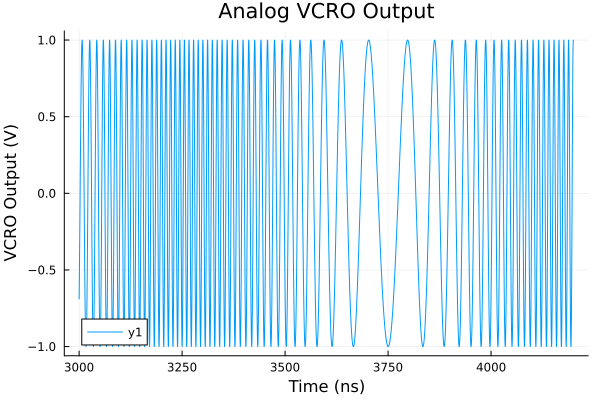

In [6]:

# Simulate
N = 12000
ts = zeros(N)
ys = zeros(N)

for i in 1:N
    ts[i] = vco.t
    ys[i] = VCRO.analog_output(vco)
    VCRO.update!(vco)
end

# Plot
plot(ts .* 1e9, ys, xlabel="Time (ns)", ylabel="VCRO Output (V)", title="Analog VCRO Output")

# Power Spectral Desnsity of Noise

In [12]:
using FFTW, DSP, Statistics, Plots
using DSP
using Random 

function plot_psd(signal::Vector{Float64}, fs::Float64; title_str="PSD")
    N = length(signal)
    window = hanning(N)
    win_signal = signal .* window

    # Compute FFT without resizing
    S = fft(win_signal)
    S = S[1:div(N,2)]  # one-sided spectrum

    # Power Spectral Density
    psd = abs2.(S) ./ (sum(window.^2) * fs)
    faxis = fs .* (0:div(N,2)-1) ./ N

    plot(faxis ./ 1e6, 10 .* log10.(psd .+ eps()),
         xlabel="Frequency (MHz)", ylabel="PSD (dB/Hz)",
         title=title_str, legend=false)
end

plot_psd (generic function with 1 method)

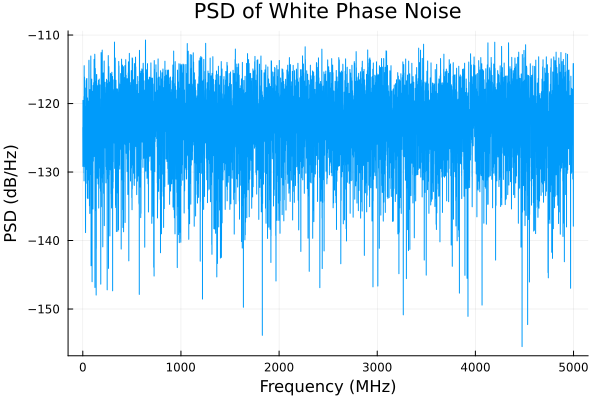

In [13]:
N = 2^14
fs = 10e9
ϕ_noise = randn(N) * 1e-1

plot_psd(ϕ_noise, fs, title_str="PSD of White Phase Noise")

In [14]:
function generate_flicker_noise(N::Int, σ::Float64, α::Float64)
    noise = zeros(Float64, N)
    ϕ = 0.0
    for i in 1:N
        η = randn() * σ
        ϕ = α * ϕ + η
        noise[i] = ϕ
    end
    return noise
end

generate_flicker_noise (generic function with 1 method)

In [15]:
function add_thermal_noise(signal::Vector{Float64}, σ_thermal::Float64)
    return signal .+ randn(length(signal)) .* σ_thermal
end

add_thermal_noise (generic function with 1 method)

In [16]:
function simulate_vcro_output(N::Int, fs::Float64, f_c::Float64, flicker_noise::Vector{Float64})
    dt = 1 / fs
    t = collect(0:N-1) .* dt

    # Integrate frequency (constant) + noise → phase
    ω = 2π * f_c
    phase = ω .* t .+ flicker_noise

    return sin.(phase), t
end

simulate_vcro_output (generic function with 1 method)

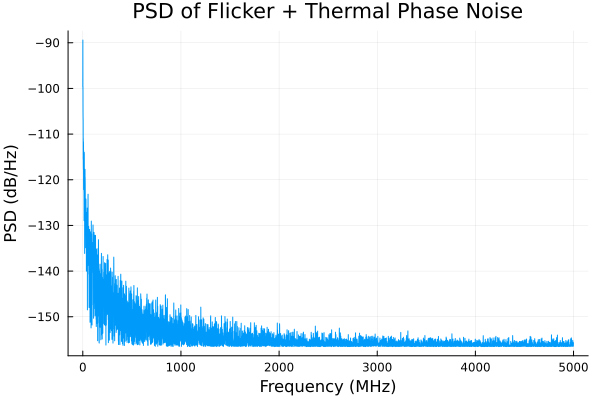

In [17]:
# --- Parameters ---
N = 2^14
fs = 10e9       # Sampling rate
f_c = 100e6     # Center frequency of VCRO
α = 0.9999      # Flicker memory
σ_flicker = 1e-3
σ_thermal = 1e-4

# --- Generate flicker + thermal noise ---
flicker = generate_flicker_noise(N, σ_flicker, α)
total_noise = add_thermal_noise(flicker, σ_thermal)

# --- Plot PSD of phase noise alone ---
plot_psd(total_noise, fs, title_str="PSD of Flicker + Thermal Phase Noise")


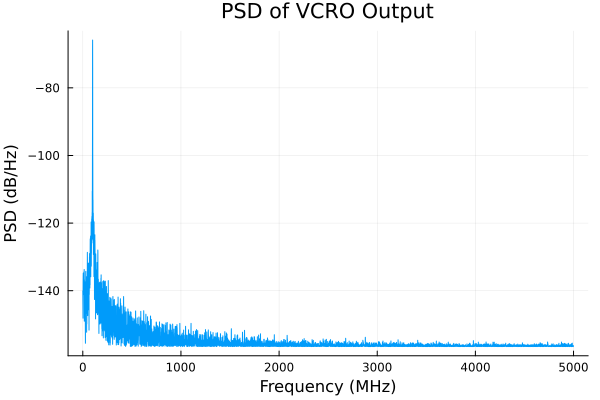

In [20]:

# # --- Simulate VCO Output ---
vcro_output, t = simulate_vcro_output(N, fs, f_c, total_noise)

# # --- Plot Output Signal ---
plot(t[1:2000] .* 1e9, vcro_output[1:2000], xlabel="Time (ns)", ylabel="VCRO Output", title="Noisy VCRO Output")

# # --- Plot Output PSD ---
plot_psd(vcro_output, fs, title_str="PSD of VCRO Output")

# Mixed domain simulation

In [2]:
using DifferentialEquations
using Plots

In [3]:

# -------------------------------------------------------------------
# 1) Define the piecewise-linear current-source inverter model
# -------------------------------------------------------------------
struct InverterPLCS
    Vth::Float64
    kn::Float64
    kp::Float64
    α::Float64
    β::Float64
    C::Float64
    VDD::Float64

    # inner constructor for keywords
    function InverterPLCS(; Vth, kn, kp, α, β, C, VDD)
        new(Vth, kn, kp, α, β, C, VDD)
    end
end


"Compute net current into the load: I_p (up) minus I_n (down)"
function driver_current(inv::InverterPLCS, Vin, Vout)
    In = Vin ≥ inv.Vth ? inv.kn * Vout^inv.α           : 0.0
    Ip = Vin ≤ inv.Vth ? inv.kp * (inv.VDD - Vout)^inv.β : 0.0
    return Ip - In
end

# -------------------------------------------------------------------
# 2) ODE: C dVout/dt = Ip(Vin, Vout) - In(Vin, Vout)
# -------------------------------------------------------------------
function inverter_ode!(du, u, p, t)
    Vout = u[1]
    Vin  = p.Vin(t)
    du[1] = driver_current(p.inv, Vin, Vout) / p.inv.C
end

# -------------------------------------------------------------------
# 3) Define an input waveform (here a 1 V step at 1 ns)
# -------------------------------------------------------------------
Vin_fun(t) = t < 0.5e-9 ? 0.0 : 1.0

# -------------------------------------------------------------------
# 4) Instantiate inverter + parameters
# -------------------------------------------------------------------
inv = InverterPLCS(
    Vth = 0.5,    # V
    kn  = 1e-3,   # A/V^α
    kp  = 1e-2,   # A/V^β
    α   = 1.0,
    β   = 1.0,
    C   = 1e-12,  # F
    VDD = 1.0     # V
)

u0    = [0.0]           # initial Vout
tspan = (0.0, 5e-9)     # simulate 0 → 5 ns
p     = (inv = inv, Vin = Vin_fun)

prob = ODEProblem(inverter_ode!, u0, tspan, p)
#sol  = solve(prob, Tsit5(); reltol=1e-6, abstol=1e-9)

# 1. Control output times with saveat
# By default solve only returns as many points as the adaptive integrator thinks it needs. If you want, say, a point every 10 ps, do:
t_steps = 0.0:10e-12:5e-9       # from 0 to 5 ns in 10 ps steps
sol = solve(
    prob, Tsit5();
    reltol=1e-6, abstol=1e-9,
    saveat = t_steps
)

# 2. Reduce tolerances for a finer internal step If you also want the integrator itself to take smaller steps (not just at output), tighten
# sol = solve(
#     prob, Tsit5();
#     dt     = 5e-12,       # initial step = 5 ps
#     dtmin  = 1e-12,       # minimum step
#     dtmax  = 20e-12,      # maximum step
#     adaptive = false,     # turn off adaptivity
#     saveat   = 0:5e-12:5e-9
# )

# 3. Force a fixed time step If you’d rather march with a constant Δt instead of an adaptive solver, pick an explicit method (e.g. Euler()) or force a fixed step:
# sol = solve(
#     prob, Tsit5();
#     dt     = 5e-12,       # initial step = 5 ps
#     dtmin  = 1e-12,       # minimum step
#     dtmax  = 20e-12,      # maximum step
#     adaptive = false,     # turn off adaptivity
#     saveat   = 0:5e-12:5e-9
# )

# Or with forward euler
# sol = solve(
#     prob, Euler();
#     dt     = 5e-12,
#     saveat = 0:5e-12:5e-9
# )


retcode: Success
Interpolation: 1st order linear
t: 501-element Vector{Float64}:
 0.0
 1.0e-11
 2.0e-11
 3.0e-11
 4.0e-11
 4.9999999999999995e-11
 6.0e-11
 6.999999999999999e-11
 8.0e-11
 9.0e-11
 ⋮
 4.9199999999999996e-9
 4.929999999999999e-9
 4.94e-9
 4.95e-9
 4.9599999999999994e-9
 4.97e-9
 4.98e-9
 4.9899999999999995e-9
 5.0e-9
u: 501-element Vector{Vector{Float64}}:
 [0.0]
 [0.0951626406488417]
 [0.1812692408652209]
 [0.25918177457594005]
 [0.3296799516783524]
 [0.39346934000107087]
 [0.4511883615885986]
 [0.5034146936038251]
 [0.5506710415520923]
 [0.5934303348708656]
 ⋮
 [0.011953641035962624]
 [0.01183470043942667]
 [0.011716943288984937]
 [0.011600357806454463]
 [0.01148493233685611]
 [0.01137065534841446]
 [0.01125751543240593]
 [0.011145501282279252]
 [0.011034601691575295]

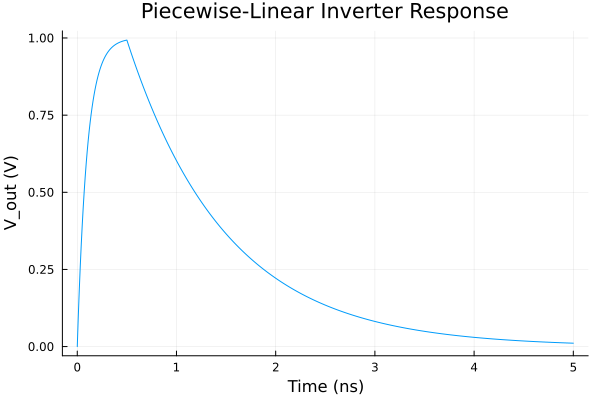

In [4]:

# -------------------------------------------------------------------
# 5) Plot the result
# -------------------------------------------------------------------
plot(sol.t .* 1e9, getindex.(sol.u,1);
     xlabel = "Time (ns)",
     ylabel = "V_out (V)",
     title  = "Piecewise-Linear Inverter Response",
     legend = false)


In [5]:
function bandlimited_square_wave(t, f0, n_harmonics)
    y = 0.0
    for k in 1:2:(2n_harmonics - 1)
        y += sin(2π * k * f0 * t) / k
    end
    return (4/π) * y
end

# Use as
Vin_fun(t) = bandlimited_square_wave(t, 1e9, 15)


Vin_fun (generic function with 1 method)

In [6]:
using SpecialFunctions  # for erf

function gaussian_edge_square_wave_scalar(t, f0; rise_time=50e-12)
    Tb = 1/f0
    σ  = rise_time / (2√(2log(9)))
    # how many edges have stepped by time t?
    n_edges = floor(Int, t/Tb) + 1
    v = 0.0
    for i in 0:(n_edges-1)
        τ = i*Tb
        # amplitude alternates +1, -1:
        A = iseven(i) ? 1.0 : -1.0
        v += 0.5*A*(1 + erf((t-τ)/(√2*σ)))
    end
    return v
end

# Use as:
Vin_fun(t) = gaussian_edge_square_wave_scalar(t, 1e9; rise_time=50e-12)


Vin_fun (generic function with 1 method)

In [7]:
tmax=20e-9
prob = ODEProblem(inverter_ode!, u0, (0.0, tmax), (inv=inv, Vin=Vin_fun))
sol  = solve(prob, Tsit5(); saveat=0:1e-11:tmax)


retcode: Success
Interpolation: 1st order linear
t: 2001-element Vector{Float64}:
 0.0
 1.0e-11
 2.0e-11
 3.0e-11
 4.0e-11
 4.9999999999999995e-11
 6.0e-11
 6.999999999999999e-11
 8.0e-11
 9.0e-11
 ⋮
 1.992e-8
 1.9929999999999997e-8
 1.994e-8
 1.995e-8
 1.9959999999999998e-8
 1.997e-8
 1.9979999999999998e-8
 1.999e-8
 2.0e-8
u: 2001-element Vector{Vector{Float64}}:
 [0.0]
 [5.50135685274689e-5]
 [5.446617437464281e-5]
 [5.392422685902946e-5]
 [5.338767120594336e-5]
 [5.285645377293358e-5]
 [5.2330521727730885e-5]
 [5.180982270793373e-5]
 [5.129430482100822e-5]
 [5.078391664428812e-5]
 ⋮
 [0.9999326178300686]
 [0.999939030138096]
 [0.9999448317788396]
 [0.999950081348113]
 [0.9999548317016785]
 [0.9999591300339765]
 [0.9999630193154584]
 [0.9999665384928964]
 [0.9967610077221012]

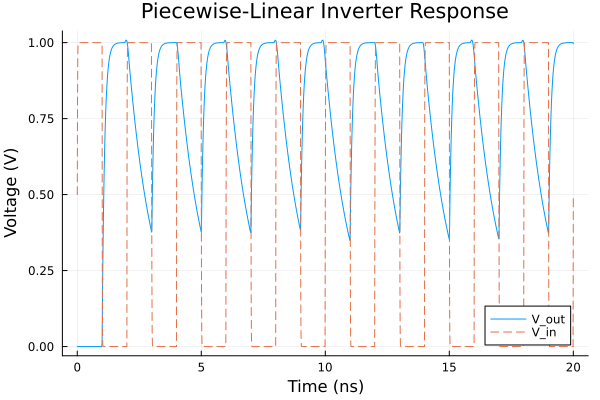

In [8]:
# time in ns for plotting
t_ns   = sol.t .* 1e9

# extract V_out
Vout   = getindex.(sol.u, 1)

# sample Vin at the solver timepoints
Vin    = Vin_fun.(sol.t)

# first plot V_out
plot(t_ns, Vout;
     label    = "V_out",
     xlabel   = "Time (ns)",
     ylabel   = "Voltage (V)",
     title    = "Piecewise-Linear Inverter Response")

# overlay Vin
plot!(t_ns, Vin;
      label     = "V_in",
      linestyle = :dash)


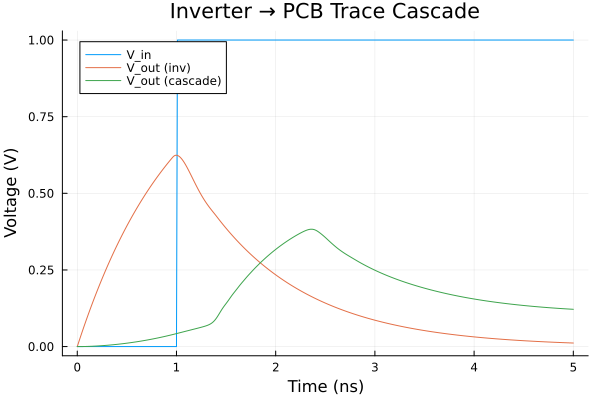

In [9]:
using DifferentialEquations, FFTW, DSP, Plots

# -------------------------------------------------------------------
# 0) (Re)define your inverter model & solver from before
# -------------------------------------------------------------------
struct InverterPLCS
    Vth::Float64
    kn::Float64
    kp::Float64
    α::Float64
    β::Float64
    C::Float64
    VDD::Float64
end
# allow keyword construction
InverterPLCS(; Vth,kn,kp,α,β,C,VDD) = InverterPLCS(Vth,kn,kp,α,β,C,VDD)

driver_current(inv::InverterPLCS, Vin, Vout) = begin
    In = Vin ≥ inv.Vth ? inv.kn * Vout^inv.α           : 0.0
    Ip = Vin ≤ inv.Vth ? inv.kp * (inv.VDD - Vout)^inv.β : 0.0
    return Ip - In
end

function inverter_ode!(du, u, p, t)
    Vout = u[1]
    du[1]  = driver_current(p.inv, p.Vin(t), Vout) / p.inv.C
end

# a simple step‐in/step‐out inverter
Vin_fun(t) = t < 1e-9 ? 0.0 : 1.0
inv = InverterPLCS(
    Vth = 0.5, kn = 1e-3, kp = 1e-3,
    α = 1.0, β = 1.0, C = 1e-12, VDD = 1.0
)
u0, tspan = [0.0], (0.0, 5e-9)
prob = ODEProblem(inverter_ode!, u0, tspan, (inv=inv, Vin=Vin_fun))
sol  = solve(prob, Tsit5(); saveat=0:1e-11:5e-9)

# pull out uniform time & inverter output
t_sim    = sol.t                  # uniform because of saveat
dt       = t_sim[2] - t_sim[1]
Vout_inv = getindex.(sol.u,1)
Vin_sim  = Vin_fun.(t_sim)

# -------------------------------------------------------------------
# 1) Define your trace ABCD/S chain (as given)
# -------------------------------------------------------------------
struct TraceParams
    length::Float64; N::Int
    sigma::Float64; w::Float64; t::Float64
    εr::Float64; tanδ::Float64
    L0::Float64; C0::Float64
end
const μ0 = 4π*1e-7

δ(f,σ) = sqrt(1/(π*f*μ0*σ))
R_per_length(f,p) = begin
    Rdc  = 1/(p.sigma*p.w*p.t)
    δf   = δ(f,p.sigma)
    Rskin= Rdc*(p.t/(2δf))*(1 - exp(-p.t/δf))
    max(Rdc,Rskin)
end
L_per_length(f,p) = p.L0*(1 + 0.1*sqrt(min(f,1e9)/1e9))
C_per_length(f,p) = p.C0*(1 + 0.05*sqrt(min(f,1e9)/1e9))
G_per_length(f,p) = 2π*f * C_per_length(f,p) * p.tanδ

function section_ABCD(f,p::TraceParams)
    Δℓ, ω = p.length/p.N, 2π*f
    R = R_per_length(f,p)*Δℓ
    L = L_per_length(f,p)*Δℓ
    C = C_per_length(f,p)*Δℓ
    G = G_per_length(f,p)*Δℓ
    Z, Y = R + im*ω*L, G + im*ω*C
    A = 1 + Z*Y/2
    B = Z
    Cmat = Y*(1 + Z*Y/4)
    D = A
    return [A B; Cmat D]
end
cascade_ABCD(f,p) = section_ABCD(f,p)^p.N

function ABCD_to_S(abcd::Matrix{ComplexF64}, Z0::Float64)
    A,B,Cmat,D = abcd[1,1],abcd[1,2],abcd[2,1],abcd[2,2]
    denom = A + B/Z0 + Cmat*Z0 + D
    S11 = (A + B/Z0 - Cmat*Z0 - D) / denom
    S21 = 2/denom
    S12 = 2*(A*D - B*Cmat) / denom
    S22 = (-A + B/Z0 - Cmat*Z0 + D) / denom
    return S11,S21,S12,S22
end

# instantiate
params = TraceParams(
    0.2, 100, 5.8e7, 0.2e-3, 35e-6, 4.3, 0.02, 400e-9, 100e-12
)
# characteristic impedance at f→0
Z0 = sqrt(params.L0/params.C0)

# -------------------------------------------------------------------
# 2) Build frequency response H[k] = S21(f_k)
# -------------------------------------------------------------------
Nf = length(t_sim)
fs = 1/dt
df = fs/Nf
# freq vector for FFT (0…fs*(Nf-1)/Nf)
f_vec = (0:Nf-1) .* df

# extract the 2nd element (S21) directly:
H = ComplexF64[
    ABCD_to_S(cascade_ABCD(f_vec[k], params), Z0)[2]
    for k in 1:Nf
]


# -------------------------------------------------------------------
# 3) Impulse response via ifft + linear convolution
# -------------------------------------------------------------------
h = real(ifft(H))           # length Nf
y_full = conv(Vout_inv, h)  # length = Nf + Nf - 1
# extract first Nf samples and scale by Δt for correct area
Vout_cascade = y_full[1:Nf]      # no dt


# -------------------------------------------------------------------
# 4) Plot all three traces
# -------------------------------------------------------------------
plot(t_sim .* 1e9, [Vin_sim Vout_inv Vout_cascade];
     labels = ["V_in" "V_out (inv)" "V_out (cascade)"],
     xlabel = "Time (ns)", ylabel = "Voltage (V)",
     title  = "Inverter → PCB Trace Cascade")


In [1]:
using LinearAlgebra, FFTW, DSP, PlotlyJS, Statistics

function gaussian_edge_square_wave(t, f0; rise_time=50e-12)
    Tb = 1 / f0
    n_cycles = floor(Int, maximum(t) / Tb)
    bit_pattern = repeat([1.0, -1.0], n_cycles + 1)  # alternating pattern
    edges = 0:Tb:(n_cycles * Tb)

    # Gaussian filter (rise_time = 10-90% rise)
    σ = rise_time / (2sqrt(2log(9)))  # Gaussian std dev for 10–90% rise time
    dt = t[2] - t[1]
    kernel_len = Int(round(6σ / dt))
    times = (-kernel_len:kernel_len) .* dt
    g_kernel = exp.(-times.^2 ./ (2σ^2))
    g_kernel ./= sum(g_kernel)  # normalize

    # Step train (ideal transitions)
    v = zeros(length(t))
    for (i, τ) in enumerate(edges)
        v .+= bit_pattern[i] .* (t .>= τ)
    end

    # Full convolution
    conv_result = DSP.conv(v, g_kernel)
    start_idx = div(length(conv_result) - length(t), 2) + 1
    return conv_result[start_idx:start_idx+length(t)-1]
end

function bandlimited_square_wave(t, f0, n_harmonics)
    y = zeros(length(t))
    for k in 1:2:(2n_harmonics - 1)  # odd harmonics
        y .+= sin.(2π * k * f0 .* t) / k
    end
    return (4/π) .* y
end




bandlimited_square_wave (generic function with 1 method)

# S-Param simulations

In [ ]:
using LinearAlgebra
using FFTW
using DSP          # for unwrap
using Plots        # high-level plotting interface
plotlyjs()          # switch to interactive plotting backend
using Interpolations  # for S21 interpolation in time domain

# -------------------------
# Parameter container for the trace
# -------------------------
struct TraceParams
    length::Float64       # total length of trace (m)
    N::Int                # number of lumped sections
    sigma::Float64        # conductivity of copper (S/m)
    w::Float64            # trace width (m)
    t::Float64            # trace thickness (m)
    εr::Float64           # relative permittivity of dielectric
    tanδ::Float64         # dielectric loss tangent
    L0::Float64           # base inductance per unit length (H/m)
    C0::Float64           # base capacitance per unit length (F/m)
end

# Default LVDS-like trace parameters
params = TraceParams(
    0.2,        # 20 cm length
    100,        # 100 lumped sections
    5.8e7,      # copper conductivity (S/m)
    0.2e-3,     # trace width (m)
    35e-6,      # trace thickness (m)
    4.3,        # relative permittivity of FR4
    0.02,       # dielectric loss tangent
    400e-9,     # base inductance per meter (H/m)
    100e-12     # base capacitance per meter (F/m)
)

# -------------------------
# Physical constants
# -------------------------
const μ0 = 4π*1e-7        # vacuum permeability (H/m)
const c0 = 299792458.0    # speed of light in vacuum (m/s)

# -------------------------
# Frequency-dependent RLGC per unit length
# -------------------------
δ(f, σ) = sqrt(1/(π*f*μ0*σ))  # skin depth
function R_per_length(f, p::TraceParams)
    Rdc = 1/(p.sigma * p.w * p.t)
    δf = δ(f, p.sigma)
    Rskin = Rdc * (p.t/(2δf)) * (1 - exp(-p.t/δf))
    return max(Rdc, Rskin)
end
L_per_length(f, p::TraceParams) = p.L0 * (1 + 0.1 * sqrt(min(f,1e9)/1e9))
C_per_length(f, p::TraceParams) = p.C0 * (1 + 0.05 * sqrt(min(f,1e9)/1e9))
G_per_length(f, p::TraceParams) = 2π*f * C_per_length(f,p) * p.tanδ

# -------------------------
# Lumped T-network ABCD matrix for one section
# -------------------------
function section_ABCD(f, p::TraceParams)
    Δℓ = p.length / p.N
    ω = 2π * f
    R = R_per_length(f,p) * Δℓ
    L = L_per_length(f,p) * Δℓ
    C = C_per_length(f,p) * Δℓ
    G = G_per_length(f,p) * Δℓ
    Z = R + im*ω*L
    Y = G + im*ω*C
    A = 1 + Z*Y/2
    B = Z
    Cmat = Y * (1 + Z*Y/4)
    D = A
    return [A B; Cmat D]
end

# -------------------------
# Cascade N identical sections
# -------------------------
cascade_ABCD(f, p::TraceParams) = section_ABCD(f,p) ^ p.N

# -------------------------
# ABCD → S-parameters
# -------------------------
function ABCD_to_S(abcd::Matrix{ComplexF64}, Z0::Float64)
    A, B, Cmat, D = abcd[1,1], abcd[1,2], abcd[2,1], abcd[2,2]
    denom = A + B/Z0 + Cmat*Z0 + D
    S11 = (A + B/Z0 - Cmat*Z0 - D)/denom
    S21 = 2/denom
    S12 = 2*(A*D - B*Cmat)/denom
    S22 = (-A + B/Z0 - Cmat*Z0 + D)/denom
    return S11, S21, S12, S22
end

# -------------------------
# Frequency-domain S-parameter sweep
# -------------------------
f_ref = range(1e9, stop=10e9, length=500)
S11 = ComplexF64[]; S21 = ComplexF64[]; φ11 = Float64[]; φ21 = Float64[]
Z0_ref = 50.0
for f in f_ref
    abcd = cascade_ABCD(f, params)
    s11, s21, _, _ = ABCD_to_S(abcd, Z0_ref)
    push!(S11, s11)
    push!(S21, s21)
    push!(φ11, angle(s11))
    push!(φ21, angle(s21))
end
φ11u = unwrap(φ11)
φ21u = unwrap(φ21)
# Group delay via central difference
τg = Float64[]
for i in 2:length(f_ref)-1
    num = φ21u[i+1] - φ21u[i-1]
    den = 2π * (f_ref[i+1] - f_ref[i-1])
    push!(τg, -num/den)
end
v_group = [params.length/t for t in τg]

# -------------------------
# Plot S-parameters and group metrics
# -------------------------
plt1 = plot(layout=(3,2))
plot!(plt1[1], f_ref./1e9, 20*log10.(abs.(S11)), title="|S₁₁| (dB)", xlabel="Freq (GHz)", legend=false)
plot!(plt1[2], f_ref./1e9, 20*log10.(abs.(S21)), title="|S₂₁| (dB)", xlabel="Freq (GHz)", legend=false)
plot!(plt1[3], f_ref./1e9, φ21u, label="∠S₂₁", legend=:bottomleft)
plot!(plt1[3], f_ref./1e9, φ11u, label="∠S₁₁", title="Phases", xlabel="Freq (GHz)")
plot!(plt1[4], f_ref[2:end-1]./1e9, v_group, title="Group Velocity (m/s)", xlabel="Freq (GHz)", legend=false)
plot!(plt1[5], f_ref[2:end-1]./1e9, τg, title="Group Delay τg (s)", xlabel="Freq (GHz)", legend=false)
display(plt1)

# -------------------------
# Time-domain FM-chirp excitation and response
# -------------------------
# Precompute S21 over extended range 1–20 GHz for interpolation
f_td = range(1e9, stop=20e9, length=2000)
S21_td = [begin
    abcd = cascade_ABCD(f, params)
    _, s21, _, _ = ABCD_to_S(abcd, Z0_ref)
    s21
end for f in f_td]
mag_S21 = abs.(S21_td)
ph_S21 = angle.(S21_td)
mag_itp = interpolate((f_td,), mag_S21, Gridded(Linear()))
ph_itp  = interpolate((f_td,), ph_S21,  Gridded(Linear()))

# Chirp parameters
duration = 1e-6      # 1 µs total
fs = 200e9           # 200 GS/s
dt = 1/fs
t = 0:dt:duration
f0, f1 = 1e9, 20e9
k = (f1 - f0)/duration
ϕ_t = 2π .* (f0 .* t .+ 0.5 .* k .* t.^2)
input_td = cos.(ϕ_t)
# Response via envelope approximation
inst_f = f0 .+ k .* t
output_td = mag_itp.(inst_f) .* cos.(ϕ_t .+ ph_itp.(inst_f))

# Plot time-domain signals (zoom into first 40 ns)
plt2 = plot(layout=(2,1), xlabel="Time (ns)")
plot!(plt2[1], 1e9 .* t, input_td, title="Input FM Chirp", legend=false)
plot!(plt2[2], 1e9 .* t, output_td, title="Output after Equalizer", legend=false)
display(plt2)


# Worse way of doing circuit analysis

But with good coding methods

In [2]:
using LinearAlgebra
using FFTW
using DSP
using PlotlyJS

# -------------------------
# Trace parameter container
# -------------------------
Base.@kwdef mutable struct TraceParams
    length::Float64 = 0.2
    N::Int = 100
    sigma::Float64 = 5.8e7
    w::Float64 = 0.2e-3
    t::Float64 = 35e-6
    εr::Float64 = 4.3
    tanδ::Float64 = 0.02
    L0::Float64 = 400e-9
    C0::Float64 = 100e-12
end

const μ0 = 4π*1e-7
const c0 = 299792458.0

δ(f,σ) = sqrt(1 / (π * f * μ0 * σ))
function R_per_length(f,p)
    Rdc = 1 / (p.sigma * p.w * p.t)
    δf = δ(f, p.sigma)
    Rskin = Rdc * (p.t / (2δf)) * (1 - exp(-p.t/δf))
    return max(Rdc, Rskin)
end
L_per_length(f,p) = p.L0 * (1 + 0.1 * sqrt(min(f, 1e9) / 1e9))
C_per_length(f,p) = p.C0 * (1 + 0.05 * sqrt(min(f, 1e9) / 1e9))
G_per_length(f,p) = 2π * f * C_per_length(f,p) * p.tanδ

# -------------------------
# Component Definitions
# -------------------------
abstract type Block end

mutable struct Source <: Block
    Rsrc::Float64
    waveform::Vector{Float64}
end

mutable struct ShuntCap <: Block
    C::Float64
end

mutable struct DelayLine <: Block
    params::TraceParams
    fs::Float64
    f_signal::Float64
end

# -------------------------
# Block Processing
# -------------------------
function process(b::Source, _::Vector{Float64}, t::Vector{Float64})
    return b.waveform
end

function process(b::ShuntCap, input::Vector{Float64}, t::Vector{Float64})
    dt = t[2] - t[1]
    RC = 50 * b.C  # Assume source drives 50Ω
    α = dt / (RC + dt)
    y = similar(input)
    y[1] = input[1]
    for i in 2:length(input)
        y[i] = α * input[i] + (1 - α) * y[i-1]
    end
    return y
end

function process(b::DelayLine, input::Vector{Float64}, t::Vector{Float64})
    p = b.params
    N = p.N
    Δℓ = p.length / N
    vp = c0 / sqrt(p.εr)
    Δt = Δℓ / vp
    delay_steps = Int(round(Δt * b.fs))

    # Frequency-dependent attenuation at f_signal
    R, L, G, C = R_per_length(b.f_signal, p), L_per_length(b.f_signal, p),
                 G_per_length(b.f_signal, p), C_per_length(b.f_signal, p)
    α = sqrt((R + 2π*im*b.f_signal*L) * (G + 2π*im*b.f_signal*C)) |> real
    total_atten = exp(-α * p.length)
    att_per_seg = total_atten^(1 / N)

    buffer = copy(input)
    for _ in 1:N
        buffer = vcat(zeros(delay_steps), buffer[1:end-delay_steps]) .* att_per_seg
    end
    return buffer
end

# -------------------------
# Block Chain Simulation
# -------------------------
function simulate_chain(blocks::Vector{Block}, t::Vector{Float64})
    sig = zeros(length(t))
    for block in blocks
        sig = process(block, sig, t)
    end
    return sig
end

# -------------------------
# Amplitude Comparison
# -------------------------
function compare_amplitude(input::Vector{Float64}, output::Vector{Float64}, f::Float64, p::TraceParams)
    abcd = cascade_ABCD(f, p)
    _, s21 = ABCD_to_S(abcd, 50.0)
    gain_expected = abs(s21)

    input_peak = maximum(abs.(input))
    output_peak = maximum(abs.(output))
    gain_measured = output_peak / input_peak

    println("== Amplitude Comparison @ $(f/1e9) GHz ==")
    println("Input peak:     ", input_peak)
    println("Expected gain:  ", gain_expected)
    println("Expected peak:  ", gain_expected * input_peak)
    println("Simulated peak: ", output_peak)
    println("Measured gain:  ", gain_measured)
end

# -------------------------
# S-parameter Helper
# -------------------------
function cascade_ABCD(f,p)
    Δℓ = p.length / p.N
    ω = 2π * f
    Z = R_per_length(f,p)*Δℓ + im*ω*L_per_length(f,p)*Δℓ
    Y = G_per_length(f,p)*Δℓ + im*ω*C_per_length(f,p)*Δℓ
    A = 1 + Z*Y/2
    B = Z
    C = Y * (1 + Z*Y/4)
    D = A
    abcd_seg = [A B; C D]
    return abcd_seg^p.N
end

function ABCD_to_S(abcd,Z0)
    A,B,C,D = abcd[1,1],abcd[1,2],abcd[2,1],abcd[2,2]
    den = A + B/Z0 + C*Z0 + D
    S11 = (A + B/Z0 - C*Z0 - D)/den
    S21 = 2 / den
    return S11, S21
end


ABCD_to_S (generic function with 1 method)

== Amplitude Comparison @ 1.0 GHz ==
Input peak:     1.0000000000000002
Expected gain:  0.8717273326365556
Expected peak:  0.8717273326365558
Simulated peak: 0.8893044890959768
Measured gain:  0.8893044890959766


┌ Warning: attempting to remove probably stale pidfile
│   path = /Users/pouyan/.jlassetregistry.lock
└ @ Pidfile /Users/pouyan/.julia/packages/Pidfile/DDu3M/src/Pidfile.jl:260


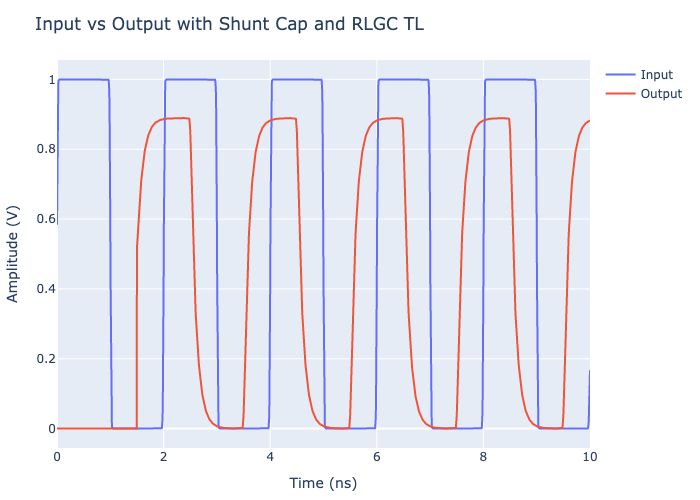

In [3]:
# -------------------------
# Run Simulation guassian input
# -------------------------
fs = 200e9
dt = 1/fs
Tsim = 10e-9
t = 0:dt:Tsim
f0 = 1e9
input = gaussian_edge_square_wave(t, f0; rise_time=50e-12)

# Block chain
params = TraceParams()
blocks = [
    Source(50.0, input),
    ShuntCap(2000e-15),  # 200 fF shunt cap
    DelayLine(params, fs, f0)
]

output = simulate_chain(blocks, collect(t))

compare_amplitude(input, output, f0, params)

# -------------------------
# Plot
# -------------------------
plt = PlotlyJS.plot([
    PlotlyJS.scatter(x=t .* 1e9, y=input, name="Input"),
    PlotlyJS.scatter(x=t .* 1e9, y=output, name="Output")
], Layout(title="Input vs Output with Shunt Cap and RLGC TL", xaxis_title="Time (ns)", yaxis_title="Amplitude (V)"))
display(plt)


== Amplitude Comparison @ 5.0 GHz ==
Input peak:     1.067309622121354
Expected gain:  0.5872209614590551
Expected peak:  0.6267465824766023
Simulated peak: 0.6408979775360262
Measured gain:  0.6004799022257438


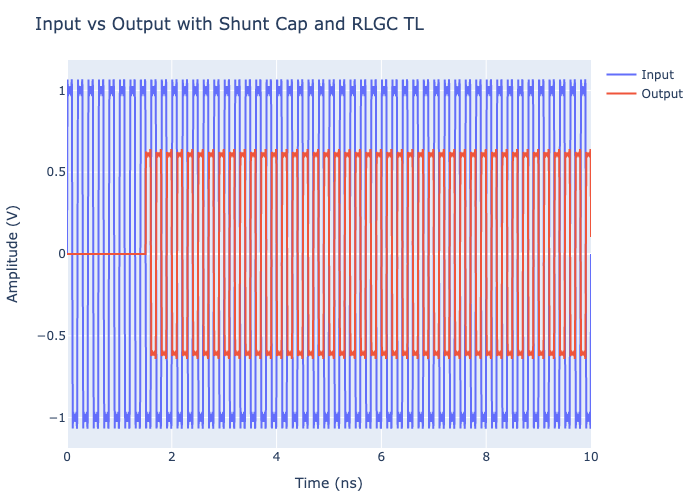

In [4]:
# -------------------------
# Run Simulation bandlimited fourier series input
# -------------------------
fs = 200e9
dt = 1/fs
Tsim = 10e-9
t = 0:dt:Tsim
f0 = 5e9
#input = gaussian_edge_square_wave(t, f0; rise_time=50e-12)
input = bandlimited_square_wave(t, f0, 15)  # 15 harmonics

# Block chain
params = TraceParams()
blocks = [
    Source(50.0, input),
    ShuntCap(20e-15),  # 200 fF shunt cap
    DelayLine(params, fs, f0)
]


output = simulate_chain(blocks, collect(t))

compare_amplitude(input, output, f0, params)

# -------------------------
# Plot
# -------------------------
plt = PlotlyJS.plot([
    PlotlyJS.scatter(x=t .* 1e9, y=input, name="Input"),
    PlotlyJS.scatter(x=t .* 1e9, y=output, name="Output")
], Layout(title="Input vs Output with Shunt Cap and RLGC TL", xaxis_title="Time (ns)", yaxis_title="Amplitude (V)"))
display(plt)